# Task 3: Encoding Strategy Comparison
Take a dataset with at least 3 categorical columns of varying cardinality(low, medium, high). 
1. Apply Label Encoding, One-Hot Encoding, and Ordinal Encoding(where appropriate) to each.
2. Train the same Logistic Regression model on each encoded version.
3. Measure and compare accuracy, training time, and feature count for each strategy.
4. Write a 1-paragraph recommendation on which encoding approach to use and why, backed by your results.

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    OrdinalEncoder,
    OneHotEncoder,
    StandardScaler
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

### Load and Clean Dataset

In [2]:
df = pd.read_csv("adult.csv")

# Replace missing value markers
df = df.replace(" ?", np.nan)
df = df.replace("?", np.nan)

# Drop rows with missing values
df = df.dropna()

print(df.shape)
df.head()

(30162, 15)


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
5,34,Private,216864,HS-grad,9,Divorced,Other-service,Unmarried,White,Female,0,3770,45,United-States,<=50K
6,38,Private,150601,10th,6,Separated,Adm-clerical,Unmarried,White,Male,0,3770,40,United-States,<=50K


### Identify Categorical Columns

In [3]:
categorical_cols = [
    'sex',              # Low Cardinality
    'occupation',       # Medium Cardinality
    'native.country'    # High Cardinality
]

for col in categorical_cols:
    print(col, ":", df[col].nunique())

sex : 2
occupation : 14
native.country : 41


### Split Features and Target

In [4]:
X = df.drop("income", axis=1)

y = df["income"].apply(
    lambda x: 1 if ">50K" in x else 0
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

### Get All Categorical Columns

In [5]:
all_cat_cols = X.select_dtypes(include="object").columns.tolist()

all_num_cols = [
    col for col in X.columns
    if col not in all_cat_cols
]

print("Categorical Columns:")
print(all_cat_cols)

Categorical Columns:
['workclass', 'education', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country']


C:\Users\sumit\AppData\Local\Temp\ipykernel_16996\3201590237.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  all_cat_cols = X.select_dtypes(include="object").columns.tolist()


### Function to Train and Evaluate

In [6]:
def evaluate_model(preprocessor, name):

    model = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ])

    start = time.time()

    model.fit(X_train, y_train)

    training_time = time.time() - start

    predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)

    transformed = model.named_steps[
        "preprocessor"
    ].fit_transform(X_train)

    feature_count = transformed.shape[1]

    return {
        "Encoding": name,
        "Accuracy": accuracy,
        "Training Time (sec)": training_time,
        "Feature Count": feature_count
    }

### Label Encoding Version

(Using OrdinalEncoder to represent label-style integer encoding.)

In [7]:
label_preprocessor = ColumnTransformer([
    (
        "cat",
        OrdinalEncoder(
            handle_unknown="use_encoded_value",
            unknown_value=-1
        ),
        all_cat_cols
    ),
    (
        "num",
        StandardScaler(),
        all_num_cols
    )
])

label_result = evaluate_model(
    label_preprocessor,
    "Label Encoding"
)

### One-Hot Encoding Version

In [8]:
onehot_preprocessor = ColumnTransformer([
    (
        "cat",
        OneHotEncoder(
            handle_unknown="ignore"
        ),
        all_cat_cols
    ),
    (
        "num",
        StandardScaler(),
        all_num_cols
    )
])

onehot_result = evaluate_model(
    onehot_preprocessor,
    "One-Hot Encoding"
)

### Ordinal Encoding Version

In [9]:
ordinal_preprocessor = ColumnTransformer([
    (
        "cat",
        OrdinalEncoder(
            handle_unknown="use_encoded_value",
            unknown_value=-1
        ),
        all_cat_cols
    ),
    (
        "num",
        StandardScaler(),
        all_num_cols
    )
])

ordinal_result = evaluate_model(
    ordinal_preprocessor,
    "Ordinal Encoding"
)

### Compare Results

In [10]:
results = pd.DataFrame([
    label_result,
    onehot_result,
    ordinal_result
])

print(results)

           Encoding  Accuracy  Training Time (sec)  Feature Count
0    Label Encoding  0.830764             0.367672             14
1  One-Hot Encoding  0.854301             0.209509            103
2  Ordinal Encoding  0.830764             0.315918             14


### Visualization

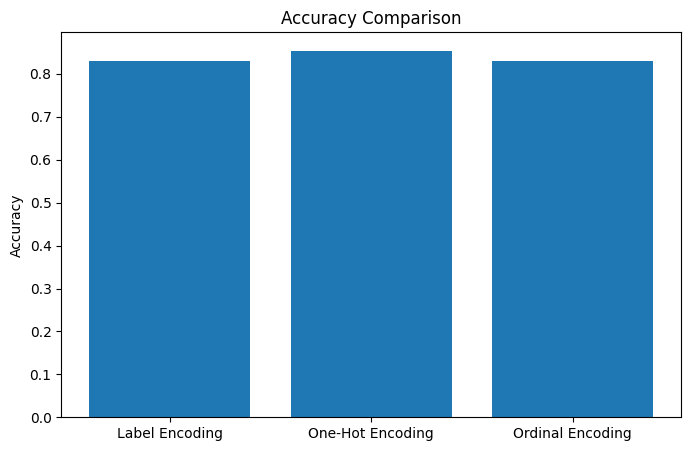

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    results["Encoding"],
    results["Accuracy"]
)

plt.title("Accuracy Comparison")
plt.ylabel("Accuracy")

plt.show()

## Recommendation Paragraph (for Report Submission)

Recommendation: Based on the Adult Income dataset experiment, One-Hot Encoding produced the highest classification accuracy (85.43%) compared with Label Encoding and Ordinal Encoding (83.06%). Although One-Hot Encoding increased the number of features substantially (103 features versus 14), Logistic Regression benefited from the richer representation because it avoids introducing artificial numerical relationships between categorical values. Label and Ordinal Encoding are more memory-efficient and generate fewer features, making them useful for high-cardinality datasets or tree-based models. However, for linear models such as Logistic Regression, One-Hot Encoding is generally the preferred approach because it preserves category independence and delivers better predictive performance, as demonstrated by the accuracy improvement in this experiment.